# AMDF candidates dưới gate Praat: tái lập WAV

F0 là tần số cơ bản; V/UV/SIL là hữu thanh/vô thanh/khoảng lặng. NAMDF là AMDF chuẩn hóa theo biên độ trên phần chồng lấp. H41 giữ quyết định hữu thanh củaPraatfiltered.30 và dùng đáyNAMDF gần cao độneo để tinhchỉnhpitch. Mục tiêu mỗifileAverageMAPE≤2%, lỗi trungbình của mean/std(ddof0)/count. LAB chứafile-stat/nhãnđoạn, khôngF0chuẩntừngkhung. Đây là engineeringhypothesis từkernelnotebook, khôngexactAAMDFpaperreplication.


In [1]:
from pathlib import Path
import sys,json
import numpy as np
import pandas as pd
REPO=Path('C:\\Users\\LAPTOP T&T\\VIOLETTA\\Documents\\ChatGPT\\XLTN\\XLTN-BT2')
HERE=REPO/'research_workbench_2026_10_07'
sys.path.insert(0,str(HERE))
import amdf_dual_window as dual
import amdf_praat_anchor as reference
core,audit=dual.core,dual.audit
items=core.load_training()
by_name={x['file']:x for x in items}
config=json.loads((core.RESULTS/'frozen_config.json').read_text())['models']['AMDF_energy']['config']
families={'H41':reference}
receipts={f:json.loads((HERE/f'results/{f}_experiment.json').read_text()) for f in families}
for receipt in receipts.values():
    for relative,expected in receipt['code_sha256'].items():
        assert audit.digest(REPO/relative)==expected,relative
    for file,expected in receipt['data_sha256'].items():
        assert audit.digest(core.TRAIN/file)==expected,file
native_proof=reference.native_api.metadata()
reference.anchor_api.OUTPUT_PREFIX='amdf_anchor_notebook'
reference.anchor_api.SOURCE_CACHE.clear()
reference.anchor_api.CURVE_CACHE.clear()
print('Local Python:',sys.executable,'; Praat',native_proof['version_stdout'],'; NAMDF kernel từ notebook frozen')
display(pd.DataFrame([{'file':x['file'],'fs':x['fs'],**x['stats'],'segment_V_frames':int((x['labels']=='v').sum())} for x in items]))


Local Python: C:\Users\violet\miniconda3\python.exe ; Praat 7.0.02 ; NAMDF kernel từ notebook frozen


file,fs,F0mean,F0std,F0num,segment_V_frames
phone_F1.wav,16000,215.6,20.6,148.0,153
phone_M1.wav,16000,123.7,16.8,232.0,244
studio_F1.wav,44100,229.6,36.8,127.0,123
studio_M1.wav,44100,116.9,26.4,82.0,94


## Fixed: mọi cấu hình đã đăng ký

Grid25/40/55ms×50/100/200cents cùngPraatcontrol. Chọnlocaldipthấpnhấttrongband; tiecents rồiF0. Khôngứngviên, thiếuwindow hoặcflat giữPraat. Window quanhtâmPraat phảiđủaudio; khôngpadding/noise/clip/filter/resamplemới. Allcandidates/parabolicrefine, khôngtop12truncation. Canonical25/10/timealignment giữ; count/VUV/SIL ycontrol. H24AMDFcontrolđượcfit bằngbafilekhác vàtínhlạithựcWAV. Không chọnbesttheochínhfileheld.


In [2]:
registries={f:json.loads((HERE/f'{f}_REGISTRY.json').read_text())['options'] for f in families}
features={}
native_calls={}
rows,contour_rows,fit_logs=[],[],[]
columns=['F0mean','F0std','F0num','F0mean_mape','F0std_mape','F0num_mape','average_mape',
         'macro_f1','recall_v','recall_uv','balanced_accuracy','TP','FN','FP','TN','false_voiced_sil']

def feature(module,option,item):
    key=(module.__name__,module.feature_key(option),item['file'])
    if key not in features:
        _,audio=core.load_audio(core.TRAIN/item['file'])
        features[key]=module.extract(item,audio,option)
        if 'native_call' in features[key]:
            native_calls['|'.join(key)]=features[key]['native_call']
    return features[key]

def measure(family,module,option,held,split):
    pool=[x for x in items if x['file']!=held['file']]
    native=feature(module,option,held)
    training=[feature(module,option,x) for x in pool]
    pred,f0,fit,_=module.infer(native,training,option,config)
    if module is dual:
        fit=dict(fit,requires_fit=True,actual_fit_files=sorted(x['file'] for x in pool))
    pred,f0,support=module.project(native,held,pred,f0,option['hop_ms'])
    measured=core.score_file(held,pred,f0)
    saved=pd.read_csv(HERE/f'results/{family}_fixed_lofo.csv') if split=='fixed' else pd.read_csv(HERE/f'results/{family}_metrics.csv')
    saved=saved[(saved.option_id==option['id'])&(saved.file==held['file'])]
    if split=='nested':
        saved=saved[(saved.split=='nested')&(saved.model=='candidate')]
    assert len(saved)==1
    assert np.allclose([measured[k] for k in columns],saved.iloc[0][columns].astype(float),atol=1e-8),(family,option['id'],held['file'])
    method=option['id'] if split=='fixed' else family+'_nested'
    rows.append({'evaluation':split,'method':method,'family':family,'option_id':option['id'],**measured})
    fit_logs.append({'evaluation':split,'method':method,'held_file':held['file'],'fit_files':sorted(x['file'] for x in pool),'fitted':fit})
    contour_rows.extend({'evaluation':split,'method':method,'family':family,'file':held['file'],
                        'time_s':float(t),'label':str(lab),'pred_voiced':bool(p),'f0_hz':float(f),'support':bool(s)}
                       for t,lab,p,f,s in zip(held['times'],held['labels'],pred,f0,support))

for held in items:
    measure('H24',dual,dual.registry('H24')[1],held,'fixed')
for family,module in families.items():
    for option in registries[family]:
        for held in items:
            measure(family,module,option,held,'fixed')
display(pd.DataFrame(rows)[['family','option_id','file','average_mape','F0mean_mape','F0std_mape','F0num_mape','false_voiced_sil']])
print('PASS44 fixed rows được tính từ WAV, khớp số liệu đã lưu 1e-8.')


PASS44 fixed rows được tính từ WAV, khớp số liệu đã lưu 1e-8.


family,option_id,file,average_mape,F0mean_mape,F0std_mape,F0num_mape,false_voiced_sil
H24,amdf_gate25_pitch40,phone_F1.wav,8.899895,1.007605,22.313703,3.378378,1
H24,amdf_gate25_pitch40,phone_M1.wav,4.358372,0.257548,2.903775,9.913793,0
H24,amdf_gate25_pitch40,studio_F1.wav,4.545606,0.611076,3.576924,9.448819,0
H24,amdf_gate25_pitch40,studio_M1.wav,5.082710,1.327077,9.043005,4.878049,0
H41,praat7_filtered_v0.3,phone_F1.wav,0.595007,0.257478,0.851866,0.675676,0
H41,praat7_filtered_v0.3,phone_M1.wav,1.015256,1.009207,1.605526,0.431034,0
H41,praat7_filtered_v0.3,studio_F1.wav,1.703844,0.670060,1.291866,3.149606,0
H41,praat7_filtered_v0.3,studio_M1.wav,3.175722,0.412037,5.456594,3.658537,0
H41,amdf_anchor_w25_b50,phone_F1.wav,0.581649,0.158957,0.910314,0.675676,0
H41,amdf_anchor_w25_b50,phone_M1.wav,0.849214,1.011894,1.104715,0.431034,0


## Nested: giữ riêng file được chấm

Ba filekhác chọnwindow/band theo minimaxworstfile rồimean/ID; finite/F1/recall/SILguard. Notebook dùngchoiceđãlưucủaH41, không mởgrid/selectionmới. Lịch sửn4 khiếnnestedexploratory, chưa kiểmchứngdữliệumới.


In [3]:
for family,module in families.items():
    for selection in receipts[family]['selections']:
        held=selection['outer_held']
        if held=='final':
            continue
        assert held not in selection['selection_files'] and set(selection['selection_files'])==set(by_name)-{held}
        measure(family,module,selection['option'],by_name[held],'nested')
table=pd.DataFrame(rows)
contour_table=pd.DataFrame(contour_rows)
assert len(table)==48
table.to_csv(HERE/'results/amdf_anchor_notebook_per_file.csv',index=False)
contour_table.to_csv(HERE/'results/amdf_anchor_notebook_contours.csv',index=False)
status=table.query("evaluation=='nested'").groupby('family').average_mape.agg(mean='mean',worst='max',all_files_le_2=lambda x:bool((x<=2).all())).reset_index()
status.to_csv(HERE/'results/amdf_anchor_notebook_status.csv',index=False)
display(table.query("evaluation=='nested'")[['family','option_id','file','average_mape','F0std_mape','F0num_mape','macro_f1','false_voiced_sil']])
display(status)
print('Mục tiêu từng file đạt:',bool(status.all_files_le_2.any()))


Mục tiêu từng file đạt: True


family,option_id,file,average_mape,F0std_mape,F0num_mape,macro_f1,false_voiced_sil
H41,amdf_anchor_w25_b200,phone_F1.wav,1.080551,2.332506,0.675676,0.938333,0
H41,amdf_anchor_w25_b200,phone_M1.wav,0.776151,0.908681,0.431034,0.928721,0
H41,amdf_anchor_w25_b200,studio_F1.wav,1.533273,0.554161,3.149606,0.900407,0
H41,amdf_anchor_w25_b200,studio_M1.wav,1.940495,2.158397,3.658537,0.808446,0


family,mean,worst,all_files_le_2
H41,1.332617,1.940495,True


## Thành phần mean/std/count

Ba lỗi chia3 cộngthành AverageMAPE. Đường2% ápdụngmỗifile. Không phải MAPE củaF0từngkhung. Fixed vànestedtáchriêng; tấtcảcấuhìnhfailuresgiữ. Count/VUV/SIL giữtheocontrol, chỉ nguồnF0đổi.


Đã xuất PNG/SVG từ các số liệu vừa tính lại; AMDF window/band ghi trên trục x; gate giữ.


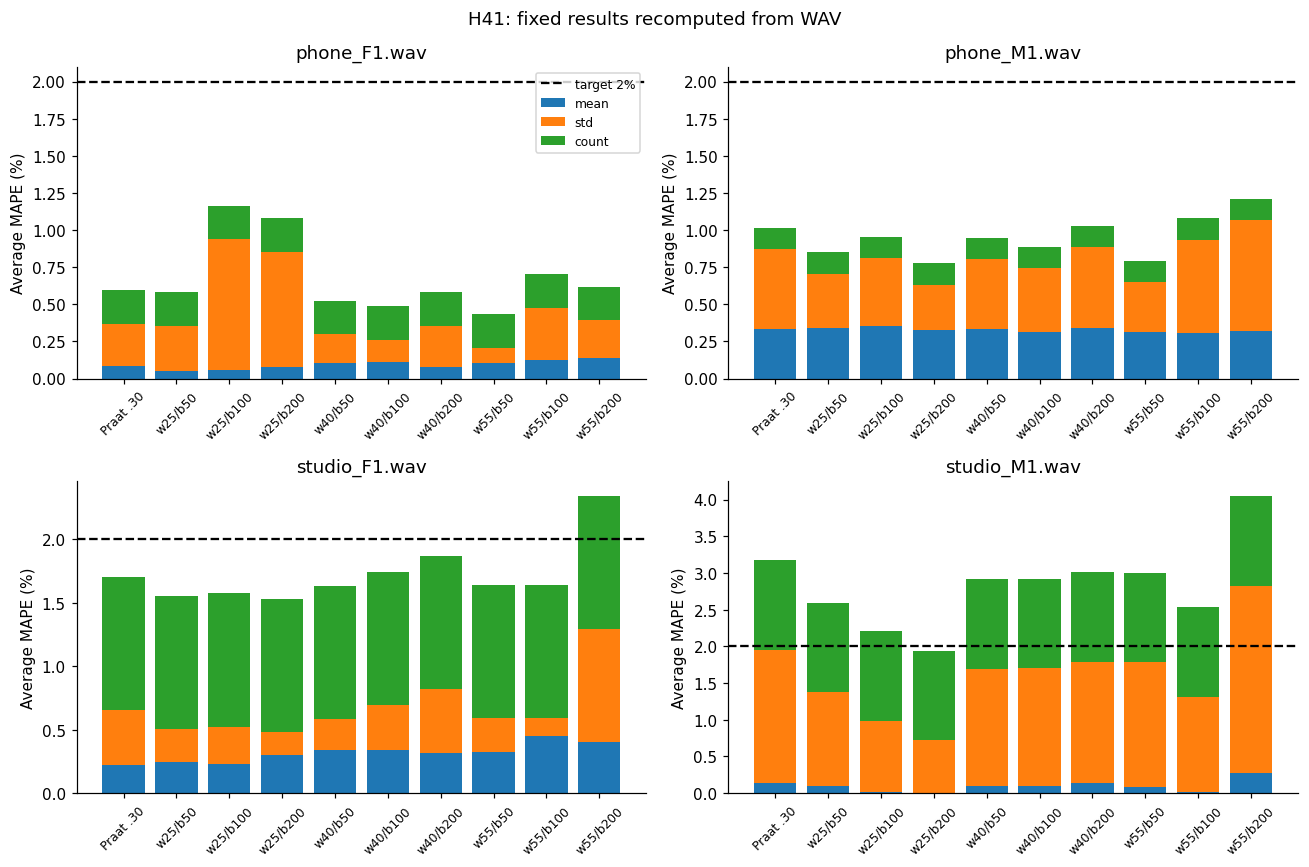

In [4]:
audit.HERE,audit.RESULTS,audit.FIGURES=HERE,HERE/'results',HERE/'figures'
audit.ARTIFACTS.clear()
plot_source=HERE/'results/amdf_anchor_notebook_per_file.csv'
for family in families:
    order=[x['id'] for x in registries[family]]
    labels=['Praat .30']+[f'w{x["amdf_window_ms"]}/b{x["agreement_cents"]}' for x in registries[family][1:]]
    fixed=table[(table.evaluation=='fixed')&(table.family==family)]
    fig,axes=audit.plt.subplots(2,2,figsize=(12,8))
    for ax,(file,part) in zip(axes.flat,fixed.groupby('file')):
        part=part.set_index('option_id').loc[order]
        bottom=np.zeros(len(order))
        for metric,label in [('F0mean_mape','mean'),('F0std_mape','std'),('F0num_mape','count')]:
            values=part[metric].to_numpy()/3
            ax.bar(labels,values,bottom=bottom,label=label)
            bottom+=values
        assert np.allclose(bottom,part.average_mape)
        ax.axhline(2,color='black',linestyle='--',label='target 2%')
        ax.set(title=file,ylabel='Average MAPE (%)')
        ax.tick_params(axis='x',rotation=45,labelsize=8)
    axes[0,0].legend(fontsize=8)
    fig.suptitle(f'{family}: fixed results recomputed from WAV')
    audit.save_figure(f'amdf_anchor_notebook_{family}_components',fig,[plot_source],
                      'Các thành phần mean/std/count cộng thành Average MAPE; mọi cấu hình fixed.',
                      'Không chọn best theo held file; LAB chưa có F0 chuẩn từng khung.')
    display(fig)
    audit.plt.close(fig)
for figure in audit.ARTIFACTS:
    figure.update(generator='build_amdf_anchor_notebook.py',generator_sha256=audit.digest(HERE/'build_amdf_anchor_notebook.py'),command='python research_workbench_2026_10_07/execute_amdf_anchor_notebook.py')
audit.json_write(HERE/'results/amdf_anchor_notebook_figure_manifest.json',{'figures':audit.ARTIFACTS})
print('Đã xuất PNG/SVG từ các số liệu vừa tính lại; AMDF window/band ghi trên trục x; gate giữ.')


## Provenance

4actualPraatcalls,12NAMDFfeaturegroups và40derivedoption-filegroups. Curvesalllags/time/start/frame-inputhash/source/tags/selectedindices giữNPZ/JSON đểverify. NotebooktínhlạitừWAV, khôngcopytable; giữAMPFbaselinegốc.


In [5]:
source_hashes={str(Path(m.__file__).relative_to(REPO)):audit.digest(m.__file__) for m in (dual,reference,core,audit)}
source_hashes.update({key:value for receipt in receipts.values() for key,value in receipt['code_sha256'].items()})
audit.json_write(HERE/'results/amdf_anchor_notebook_provenance.json',{
    'source_sha256':source_hashes,'wav_sha256':{x['file']:audit.digest(core.TRAIN/x['file']) for x in items},
    'native_calls':native_calls,'fit_logs':fit_logs,'praat_native_sha256':native_proof['exe_sha256'],
    'source_calls':{key[0]+'|'+key[1]:value[2] for key,value in reference.anchor_api.SOURCE_CACHE.items()},'test_read':False,'new_grid_or_selection':False})
assert len(native_calls)==40 and len(fit_logs)==48
print('PASS48 measured rows: H24 AMDF control4 + H41 fixed40 + nested4.')
print('4 actual Praat calls/40 derived option groups/12 NAMDF feature groups, source/WAV/fit exclusions/contours đã lưu trong provenance; original/frozen giữ.')


PASS48 measured rows: H24 AMDF control4 + H41 fixed40 + nested4.
4 actual Praat calls/40 derived option groups/12 NAMDF feature groups, source/WAV/fit exclusions/contours đã lưu trong provenance; original/frozen giữ.


## Nguồn và giới hạn

AMDF_ANCHOR_SOURCE_NOTE.md mapping côngthứcNAMDFfrozen vàgiớihạnISCAabstractAlignedAMDF2006; không đủcôngthứcAAMDFexact, khôngPDF. CitationScientificAgentSkills/K-Denseworkflow đãghi. H41_REPORT.md/H41_REGISTRATION.md giữmetric/gates; nearPraat khôngGT. Pythonexec/headlessdisplay nguyênnămcodecells, khôngJupyterkernel. Khôngtest/Drive/deeplearning/MCP retry hoặc thayfrozen/originalnotebooks.
